In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pyomo.environ import *
from model_00 import model00
from model_01 import model01
from run_model import get_results


In [2]:
parameters = {
    "capacity": 2, # MWh
    "duration": 4, # hours
    "efficiency": 0.85 ** 0.5, # %
    "fade_factor": 0.0,
    "eol": 0.8, # %
    "dod_min": 0.0, # %
    "dod_max": 1.0, # %
    "soc_0": 0.0, # %
    "soh" : 1.0, # %
    "lifetime" : 10 # Years
}
results_00 = get_results(model01(), parameters)
sum(results_00["Profit ($)"])

23772.87812247823

In [3]:
results_00

,Price ($/MWh),Charge (MW),Discharge (MW),SOC (MWh),Grid Transaction ($),BESS Degradation Cost ($),Profit ($),Remaining Capacity (%),Capacity Degradation (MWh)
Time,,,,,,,,,
2024-01-01 00:15:00,12.51,0.25,0.0,0.057622,-0.781875,0.0,-0.781875,100.0,0.0
2024-01-01 00:30:00,13.28,0.25,0.0,0.115244,-0.830000,0.0,-0.830000,100.0,0.0
2024-01-01 00:45:00,14.41,0.25,0.0,0.172866,-0.900625,0.0,-0.900625,100.0,0.0
2024-01-01 01:00:00,15.08,0.25,0.0,0.230489,-0.942500,0.0,-0.942500,100.0,0.0
2024-01-01 01:15:00,15.65,0.25,0.0,0.288111,-0.978125,0.0,-0.978125,100.0,0.0
...,...,...,...,...,...,...,...,...,...
2024-12-30 23:00:00,15.14,0.25,0.0,1.017034,-0.946250,0.0,-0.946250,100.0,0.0
2024-12-30 23:15:00,14.75,0.25,0.0,1.074656,-0.921875,0.0,-0.921875,100.0,0.0
2024-12-30 23:30:00,14.30,0.25,0.0,1.132278,-0.893750,0.0,-0.893750,100.0,0.0


Text(0.5, 0, 'Date')

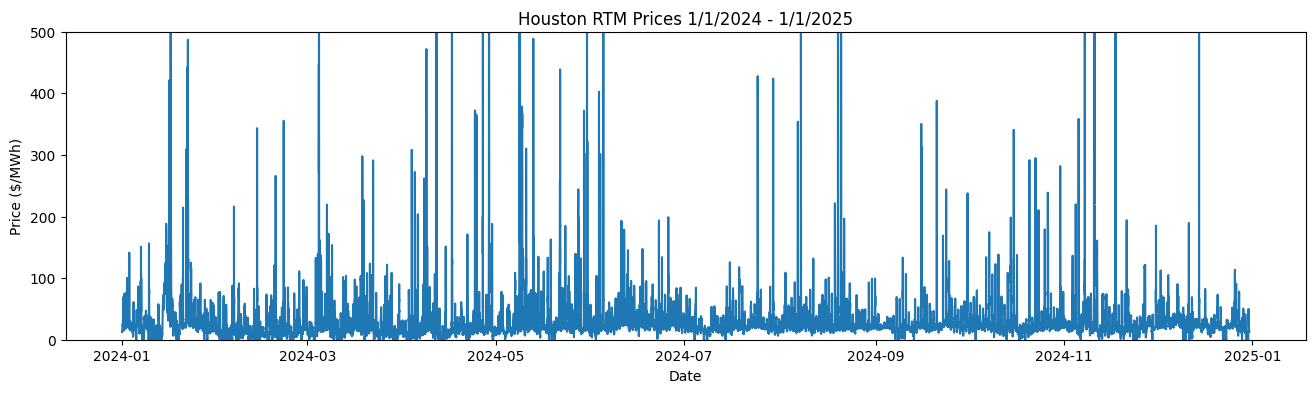

In [4]:
fig, ax = plt.subplots(figsize=(16,4))
plt.plot(results_00.index, results_00["Price ($/MWh)"])
plt.ylim(0,500)
plt.title("Houston RTM Prices 1/1/2024 - 1/1/2025")
plt.ylabel("Price ($/MWh)")
plt.xlabel("Date")

In [5]:
parameters = {
    "capacity": 2, # MWh
    "duration": 4, # hours
    "efficiency": 0.85 ** 0.5, # %
    "fade_factor": 2.71e-5,
    "eol": 0.8, # %
    "dod_min": 0.0, # %
    "dod_max": 1.0, # %
    "soc_0": 0.0, # %
    "soh" : 1.0, # %
    "lifetime" : 10 # Years
}
results_01 = get_results(model01(), parameters)
sum(results_01["Profit ($)"])

11533.156766724107

<Axes: xlabel='Time'>

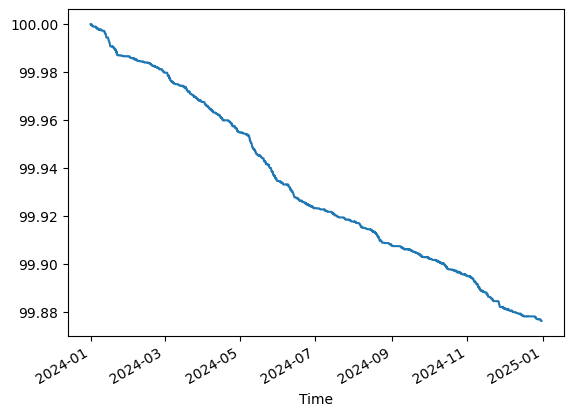

In [6]:
results_01["Remaining Capacity (%)"].plot()

In [7]:
parameters = {
    "capacity": 2, # MWh
    "duration": 4, # hours
    "efficiency": 0.85 ** 0.5, # %
    "fade_factor": 0.0,
    "eol": 0.8, # %
    "dod_min": 0.0, # %
    "dod_max": 1.0, # %
    "soc_0": 0.0, # %
    "soh" : 1.0, # %
    "lifetime" : 10 # Years
}
results_02 = get_results(model00(), parameters)
sum(results_02["Profit ($)"])

-67118.00000000001

<Axes: xlabel='Time'>

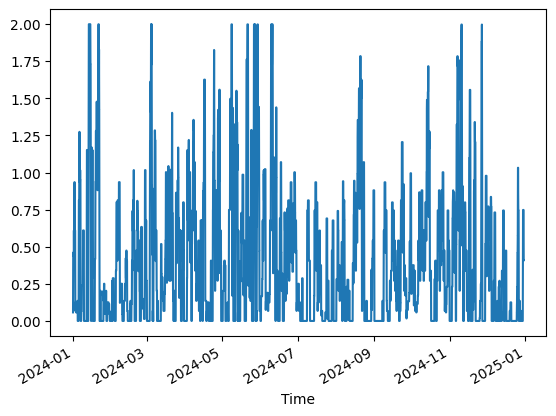

In [8]:
results_01["SOC (MWh)"].plot()

<Axes: xlabel='Time'>

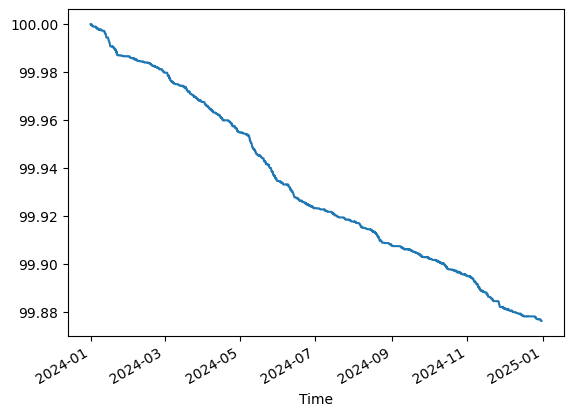

In [9]:
results_01["Remaining Capacity (%)"].plot()

<Axes: xlabel='Time'>

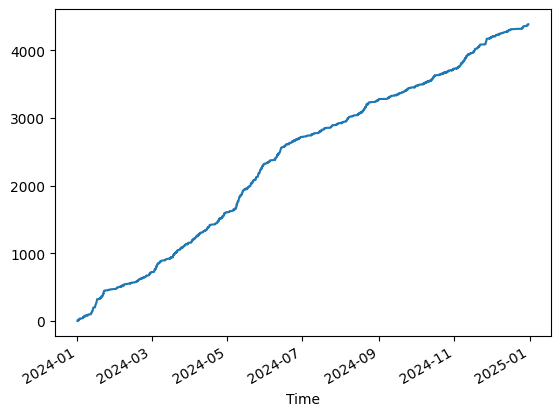

In [10]:
results_01["BESS Degradation Cost ($)"].cumsum().plot()

In [11]:
sum(results_01["BESS Degradation Cost ($)"])

4387.515467865892

In [12]:
results_00

,Price ($/MWh),Charge (MW),Discharge (MW),SOC (MWh),Grid Transaction ($),BESS Degradation Cost ($),Profit ($),Remaining Capacity (%),Capacity Degradation (MWh)
Time,,,,,,,,,
2024-01-01 00:15:00,12.51,0.25,0.0,0.057622,-0.781875,0.0,-0.781875,100.0,0.0
2024-01-01 00:30:00,13.28,0.25,0.0,0.115244,-0.830000,0.0,-0.830000,100.0,0.0
2024-01-01 00:45:00,14.41,0.25,0.0,0.172866,-0.900625,0.0,-0.900625,100.0,0.0
2024-01-01 01:00:00,15.08,0.25,0.0,0.230489,-0.942500,0.0,-0.942500,100.0,0.0
2024-01-01 01:15:00,15.65,0.25,0.0,0.288111,-0.978125,0.0,-0.978125,100.0,0.0
...,...,...,...,...,...,...,...,...,...
2024-12-30 23:00:00,15.14,0.25,0.0,1.017034,-0.946250,0.0,-0.946250,100.0,0.0
2024-12-30 23:15:00,14.75,0.25,0.0,1.074656,-0.921875,0.0,-0.921875,100.0,0.0
2024-12-30 23:30:00,14.30,0.25,0.0,1.132278,-0.893750,0.0,-0.893750,100.0,0.0


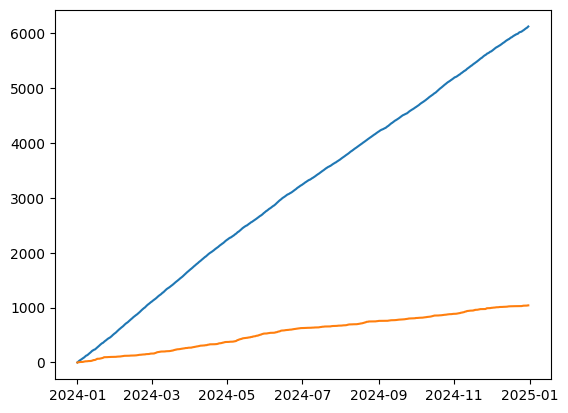

In [13]:
plt.plot((results_00["Charge (MW)"] + results_00["Discharge (MW)"]).cumsum())
plt.plot((results_01["Charge (MW)"] + results_01["Discharge (MW)"]).cumsum())